# Proyecto 6 - Stable Diffusion y generación condicionada por texto

**Línea de proyecto:** Modelos de difusión, DDPM/DDIM, Stable Diffusion y condicionamiento<br>
**Material base:** `Cuaderno25-CC0C2.ipynb` (difusión, latentes, guidance)

## Objetivo

Usar un pipeline de **Stable Diffusion** (o variante ligera) para generar imágenes a partir de prompts, mostrar el flujo **tokenización -> encoding textual -> difusión en latente -> decodificación**, y comparar dos valores de **guidance scale** analizando el trade-off entre fidelidad al prompt y diversidad visual.

## Trazabilidad

| Componente | Origen |
|---|---|
| Conceptos latentes, CFG, scheduler | `Cuaderno25-CC0C2.ipynb` |
| Pipeline diffusers y comparación guidance | Implementación propia |
| README / guía video | IA para estructura; interpretación propia |

## Importaciones

In [1]:
import os
import time
import math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image

## Configuración experimental

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

MODEL_ID = "segmind/tiny-sd"
GUIDANCE_A = 3.5
GUIDANCE_B = 9.0
NUM_INFERENCE_STEPS = 20
IMAGE_SIZE = 512
PROMPT = "Un laboratorio de inteligencia artificial futurista, estilo infografía técnica, colores azul y blanco"
NEGATIVE_PROMPT = "borroso, deforme, texto ilegible, baja calidad"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float16 if device.type == "cuda" else torch.float32

print("Dispositivo:", device)
print("Modelo:", MODEL_ID)
print("Semilla:", SEED)
print("Guidance A/B:", GUIDANCE_A, GUIDANCE_B)
print("Pasos de inferencia:", NUM_INFERENCE_STEPS)

Dispositivo: cpu
Modelo: segmind/tiny-sd
Semilla: 42
Guidance A/B: 3.5 9.0
Pasos de inferencia: 20


## Celda de verificación personal

In [3]:
STUDENT_NAME = "Rojas Huaroc, Luis Antonio"
EXECUTION_DATE = "2026-07-04"
PROJECT_TRACK = "Proyecto 6: Stable Diffusion y generación condicionada"
MODEL_NAME = MODEL_ID
VARIANT = f"Comparación guidance_scale {GUIDANCE_A} vs {GUIDANCE_B}"

print("Estudiante:", STUDENT_NAME)
print("Fecha:", EXECUTION_DATE)
print("Línea de proyecto:", PROJECT_TRACK)
print("Modelo:", MODEL_NAME)
print("Semilla:", SEED)
print("Variante:", VARIANT)
print("Frase técnica propia:", "El guidance scale interpola entre la predicción condicionada y no condicionada para controlar obediencia al prompt sin reentrenar el UNet.")


Estudiante: Rojas Huaroc, Luis Antonio
Fecha: 2026-07-04
Línea de proyecto: Proyecto 6: Stable Diffusion y generación condicionada
Modelo: segmind/tiny-sd
Semilla: 42
Variante: Comparación guidance_scale 3.5 vs 9.0
Frase técnica propia: El guidance scale interpola entre la predicción condicionada y no condicionada para controlar obediencia al prompt sin reentrenar el UNet.


## Carga del pipeline Stable Diffusion

In [4]:
from diffusers import StableDiffusionPipeline, DDIMScheduler

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    use_safetensors=False,
)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

if device.type == "cpu":
    pipe.enable_attention_slicing()

print("Componentes del pipeline:", list(pipe.components.keys()))
print("Scheduler:", pipe.scheduler.__class__.__name__)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Componentes del pipeline: ['vae', 'text_encoder', 'tokenizer', 'unet', 'scheduler', 'safety_checker', 'feature_extractor', 'image_encoder']
Scheduler: DDIMScheduler


## Evidencia interna: formas de tensores en el flujo

In [5]:
# Tokenización y encoding textual
text_inputs = pipe.tokenizer(
    PROMPT,
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt",
)
input_ids = text_inputs.input_ids.to(device)

with torch.no_grad():
    text_embeddings = pipe.text_encoder(input_ids)[0]

print("Prompt:", PROMPT)
print("input_ids shape:", tuple(input_ids.shape))
print("Embedding textual shape:", tuple(text_embeddings.shape))

# Latente inicial (ruido en espacio comprimido)
latent_channels = pipe.unet.config.in_channels
latent_h = IMAGE_SIZE // 8
latent_w = IMAGE_SIZE // 8
latents = torch.randn(
    (1, latent_channels, latent_h, latent_w),
    generator=torch.Generator(device=device).manual_seed(SEED),
    device=device,
    dtype=dtype,
)

print("Latente inicial shape:", tuple(latents.shape))
print("Interpretación: (batch, canales, H/8, W/8) por VAE de Stable Diffusion")

Prompt: Un laboratorio de inteligencia artificial futurista, estilo infografía técnica, colores azul y blanco
input_ids shape: (1, 77)
Embedding textual shape: (1, 77, 768)
Latente inicial shape: (1, 4, 64, 64)
Interpretación: (batch, canales, H/8, W/8) por VAE de Stable Diffusion


## Línea base: generación con guidance bajo

  0%|          | 0/20 [00:00<?, ?it/s]

Guidance scale: 3.5
Imagen generada: (512, 512)
Latencia (s): 408.33
Guardada en: outputs/guidance_3.5.png


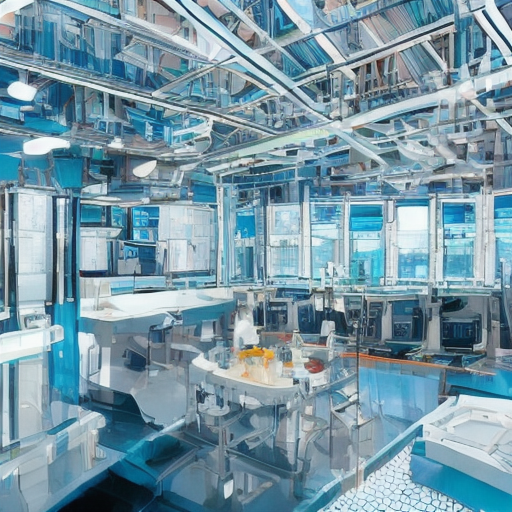

In [6]:
def generate_image(prompt: str, guidance_scale: float, seed: int = SEED) -> tuple[Image.Image, float]:
    generator = torch.Generator(device=device).manual_seed(seed)
    t0 = time.perf_counter()
    result = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE_PROMPT,
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=guidance_scale,
        generator=generator,
        height=IMAGE_SIZE,
        width=IMAGE_SIZE,
    )
    elapsed = time.perf_counter() - t0
    return result.images[0], elapsed


img_a, latency_a = generate_image(PROMPT, GUIDANCE_A)
path_a = OUTPUT_DIR / f"guidance_{GUIDANCE_A}.png"
img_a.save(path_a)

print("Guidance scale:", GUIDANCE_A)
print("Imagen generada:", img_a.size)
print("Latencia (s):", round(latency_a, 2))
print("Guardada en:", path_a)
img_a

## Modificación principal: comparar dos guidance scales

In [ ]:
img_b, latency_b = generate_image(PROMPT, GUIDANCE_B)
path_b = OUTPUT_DIR / f"guidance_{GUIDANCE_B}.png"
img_b.save(path_b)

print("Guidance scale:", GUIDANCE_B)
print("Latencia (s):", round(latency_b, 2))
print("Guardada en:", path_b)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_a)
axes[0].set_title(f"Guidance = {GUIDANCE_A}")
axes[0].axis("off")
axes[1].imshow(img_b)
axes[1].set_title(f"Guidance = {GUIDANCE_B}")
axes[1].axis("off")
plt.suptitle("Comparación visual: fidelidad vs diversidad")
plt.tight_layout()
plt.show()